In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV

# Insert warehouse name here
warehouse_name = "OE"

base = "~/Lucas_Systems_Capstone_Project"

# Load your processed data
df = pd.read_parquet(f"{base}/data/processed/oe_detailed.parquet")

# Filter for only Work Code 30
df = df[df["WorkCode"] == "30"]

In [ ]:
# Standardize data types
cols_to_numeric = ['Weight', 'Travel_Distance', 'Time_Delta_sec', 'Level']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Apply log1p transformation to mitigate the impact of skewed distributions and handle zeros
df['log_time'] = np.log1p(df['Time_Delta_sec'].fillna(0))
df['log_weight'] = np.log1p(df['Weight'].fillna(0))
df['log_distance'] = np.log1p(df['Travel_Distance'].fillna(0))

# Prepare feature matrix (X) and target vector (y)
features = ['log_weight', 'log_distance', 'Level']
target = 'log_time'
df_model = df.dropna(subset=[target] + features)
X, y = df_model[features], df_model[target]

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Train baseline Decision Tree (restricted depth for interpretability)
model = DecisionTreeRegressor(max_depth=4, min_samples_leaf=10, random_state=4)
model.fit(X_train, y_train)

# Model Evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-Squared: {r2:.4f}")

# Feature Importance: assess which features most heavily influence prediction accuracy
importance = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_})
print("\nFeature Importances:")
print(importance.sort_values(by='Importance', ascending=False))

Mean Squared Error: 1.1672
R-Squared: 0.1646

Feature Importances:
        Feature  Importance
1  log_distance    0.880720
0    log_weight    0.095983
2         Level    0.023297


Text(0.5, 1.0, 'Decision Tree: Predicting Log(Time) from Weight, Distance, and Level')

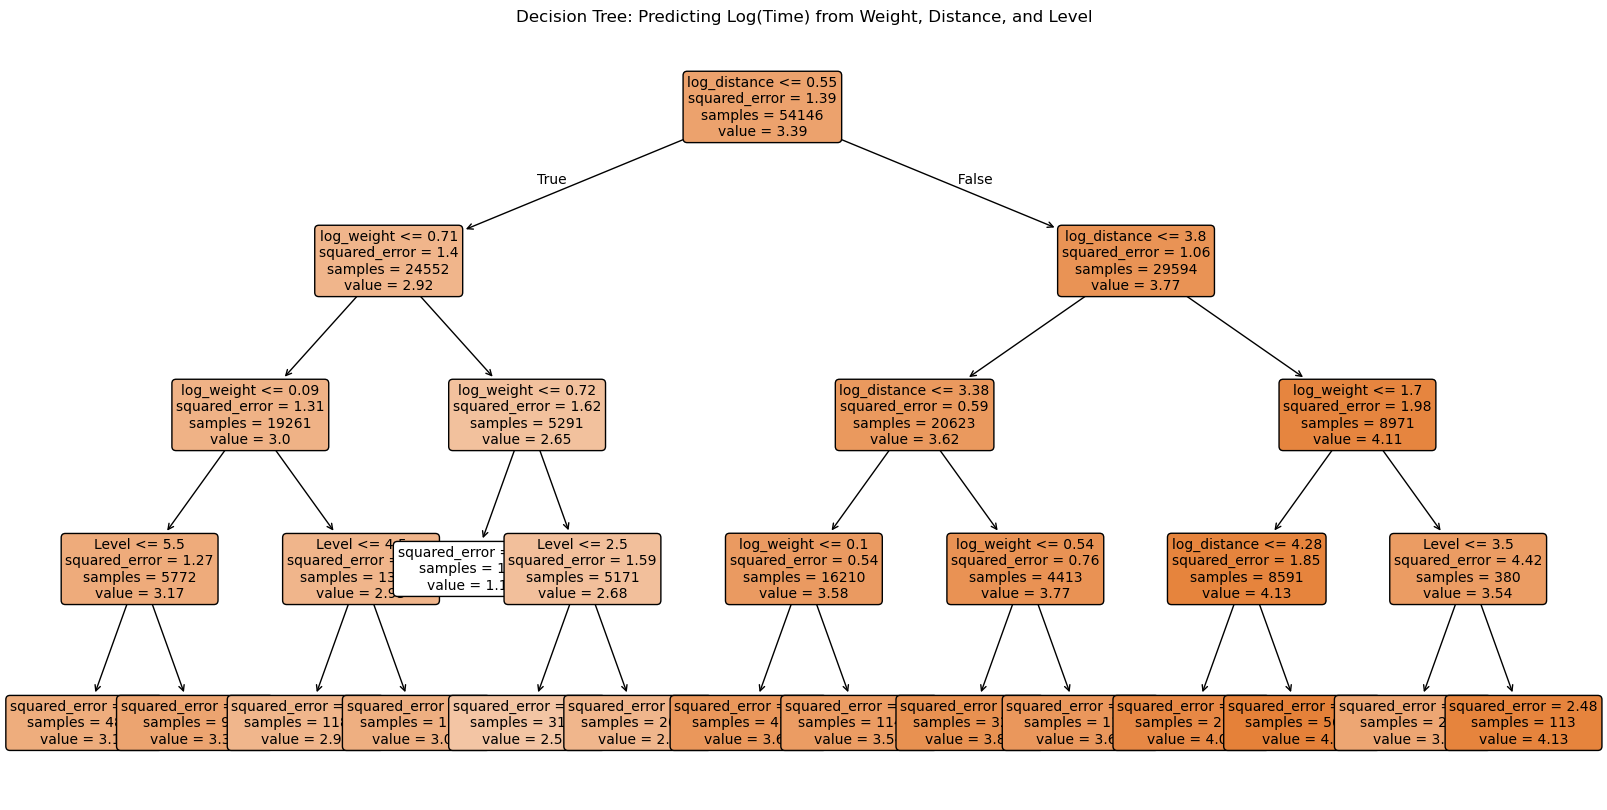

In [13]:
# Visualize the Tree
plt.figure(figsize=(20, 10))
plot_tree(model, 
          feature_names=features, 
          filled=True, 
          rounded=True, 
          precision=2, 
          fontsize=10)
plt.title("Decision Tree: Predicting Log(Time) from Weight, Distance, and Level")

In [14]:
# Reverse the log transformation
y_test_seconds = np.expm1(y_test)
y_pred_seconds = np.expm1(y_pred)

# Calculate errors in original units (seconds)
mae_seconds = mean_absolute_error(y_test_seconds, y_pred_seconds)
rmse_seconds = np.sqrt(mean_squared_error(y_test_seconds, y_pred_seconds))

print(f"Performance in Actual Seconds:\n")
print(f"Mean Absolute Error: {mae_seconds:.2f} seconds")
print(f"Root Mean Squared Error: {rmse_seconds:.2f} seconds")

# View a few actual vs predicted examples
comparison = pd.DataFrame({
    'Actual_Seconds': y_test_seconds,
    'Predicted_Seconds': y_pred_seconds,
    'Error_Seconds': y_test_seconds - y_pred_seconds
})
print("\nSample Comparisons")
print(comparison.head(10).round(2))

Performance in Actual Seconds:

Mean Absolute Error: 31.36 seconds
Root Mean Squared Error: 62.16 seconds

Sample Comparisons
       Actual_Seconds  Predicted_Seconds  Error_Seconds
65520           53.28              33.58          19.70
1503            28.18              21.96           6.23
19201           17.70              33.58         -15.88
47184           18.29              20.67          -2.37
64917           82.70              17.30          65.39
75042          113.65              33.58          80.07
37532           12.55              17.30          -4.75
11312           58.50              21.96          36.54
83474          375.69              65.41         310.28
69093           65.20              33.58          31.62


In [15]:
param_grid = {
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'min_samples_leaf': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
}
grid_search = GridSearchCV(DecisionTreeRegressor(), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")

Best parameters: {'max_depth': 10, 'min_samples_leaf': 40}


In [16]:
# Train more complex Decision Tree
complex_model = DecisionTreeRegressor(max_depth=10, min_samples_leaf=40, random_state=4)
complex_model.fit(X_train, y_train)

# Model Evaluation
y_pred = complex_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-Squared: {r2:.4f}")

# Feature Importance: assess which features most heavily influence prediction accuracy
importance = pd.DataFrame({'Feature': features, 'Importance': complex_model.feature_importances_})
print("\nFeature Importances:")
print(importance.sort_values(by='Importance', ascending=False))

Mean Squared Error: 1.1506
R-Squared: 0.1765

Feature Importances:
        Feature  Importance
1  log_distance    0.747575
0    log_weight    0.201144
2         Level    0.051281


Text(0.5, 1.0, 'Decision Tree: Predicting Log(Time) from Weight, Distance, and Level')

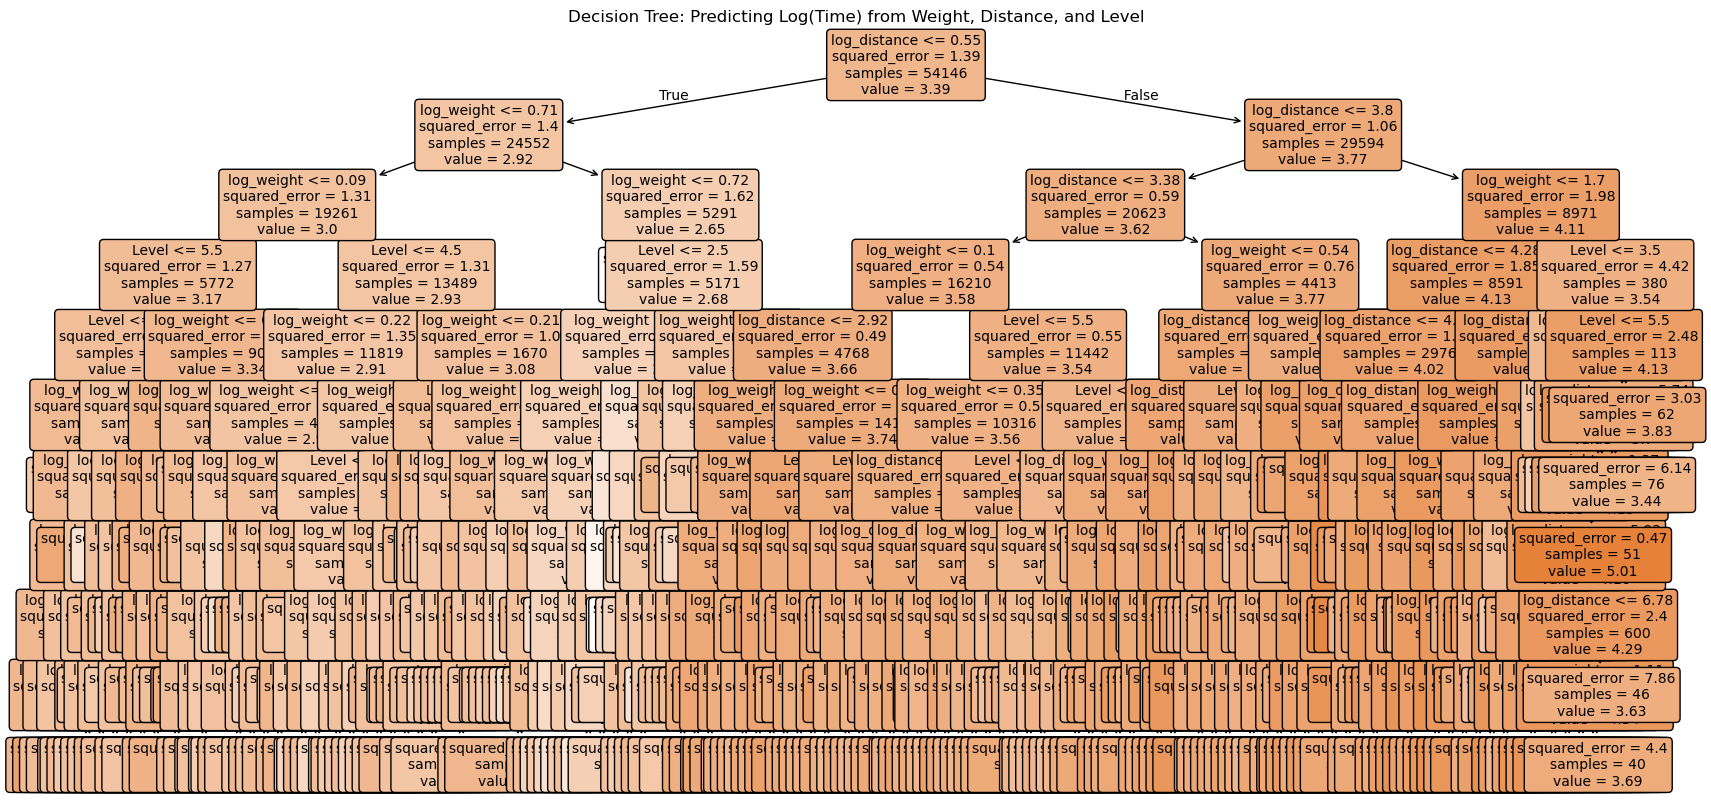

In [19]:
# Visualize the Tree
plt.figure(figsize=(20, 10))
plot_tree(complex_model, 
          feature_names=features, 
          filled=True, 
          rounded=True, 
          precision=2, 
          fontsize=10)
plt.title("Decision Tree: Predicting Log(Time) from Weight, Distance, and Level")

In [17]:
# Reverse the log transformation
y_test_seconds = np.expm1(y_test)
y_pred_seconds = np.expm1(y_pred)

# Calculate errors in original units (seconds)
mae_seconds = mean_absolute_error(y_test_seconds, y_pred_seconds)
rmse_seconds = np.sqrt(mean_squared_error(y_test_seconds, y_pred_seconds))

print(f"Performance in Actual Seconds:\n")
print(f"Mean Absolute Error: {mae_seconds:.2f} seconds")
print(f"Root Mean Squared Error: {rmse_seconds:.2f} seconds")

# View a few actual vs predicted examples
comparison = pd.DataFrame({
    'Actual_Seconds': y_test_seconds,
    'Predicted_Seconds': y_pred_seconds,
    'Error_Seconds': y_test_seconds - y_pred_seconds
})
print("\nSample Comparisons")
print(comparison.head(10).round(2))

Performance in Actual Seconds:

Mean Absolute Error: 31.01 seconds
Root Mean Squared Error: 61.87 seconds

Sample Comparisons
       Actual_Seconds  Predicted_Seconds  Error_Seconds
65520           53.28              34.22          19.06
1503            28.18              20.71           7.47
19201           17.70              32.02         -14.32
47184           18.29              22.83          -4.54
64917           82.70              16.32          66.38
75042          113.65              29.49          84.16
37532           12.55              12.98          -0.43
11312           58.50              24.72          33.78
83474          375.69              74.22         301.47
69093           65.20              40.53          24.67
